# Part 1: Given the following data find
### i. Optimal K
### ii. Centeroid (Manual)
### iii. Intertia WCSS (Manual)
### iv. Write Code and plot points 
### v. Compare manual to kmeans 

In [33]:
from sklearn.cluster import KMeans
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [34]:
# define array with given values 
X = np.array([[25, 3],
              [40, 7],
              [30, 5]])

X

array([[25,  3],
       [40,  7],
       [30,  5]])

# i. optimal number of K (Manual)

We have 3 plot points, therefore there are 3 cluster options: 
1. All points in one cluster, which would give us very high WCSS.
2. Each point in their own cluster, which would give us a WCSS of 0.
3. Having 2 clusters. Here is the elbow point that would drop sharply but not go to 0. 

Therefore, the optimal number of K is 2. 

# ii. centroid (Manual)

In [35]:
# Given the plot points, we can natually create two clusters.
# Cluster 1 has [[25,3], [30,5]]
# Cluster 2 has [40,7]

cluster1 = np.array([
    [25, 3],
    [30, 5]
])

cluster2 = np.array([
    [40, 7]
])

centroid_1 = np.mean(cluster1, axis=0)
# centroid 1 = ((25+30)/2) , ((3+5)/2) = (27.5,4)
centroid_2 = np.mean(cluster2, axis=0)
# centroid 2 = (40,7)

print("Centroid 1:", centroid_1)
print("Centroid 2:", centroid_2)

Centroid 1: [27.5  4. ]
Centroid 2: [40.  7.]


# iii. intertia WCSS

In [36]:
# Within-Cluster Sum of Squares (Intertia): is the square of absolute value between a point and its centroid 

# Cluster 1 = P1​=(25,3), P3​=(30,5), C1​=(27.5,4)
# d(P1​,C1​)^2 = (25−27.5)^2+(3−4)^2 = (−2.5)^2+(−1)^2 = 6.25+1 = 7.25
# d(P3​,C1​)^2 = (30−27.5)^2+(5−4)^2 = (2.5)^2+(1)^2 = 6.25+1 = 7.25

# Cluster 2 = P2​=(40,7), C2​=(40,7)
# d(P2​,C2​)2 = 0

# WCSS = (7.25 + 7.25) + 0 = 14.5

# squares distance function 
def squared_distance(p, c):
    return np.sum((p - c)**2)

# compute WCSS per cluster 
wcss_cluster1 = sum(squared_distance(p, centroid_1) for p in cluster1)
wcss_cluster2 = sum(squared_distance(p, centroid_2) for p in cluster2)

total_wcss = wcss_cluster1 + wcss_cluster2

print("WCSS Cluster 1:", wcss_cluster1)
print("WCSS Cluster 2:", wcss_cluster2)
print("Total WCSS:", total_wcss)

WCSS Cluster 1: 14.5
WCSS Cluster 2: 0.0
Total WCSS: 14.5


# iv. using kmeans

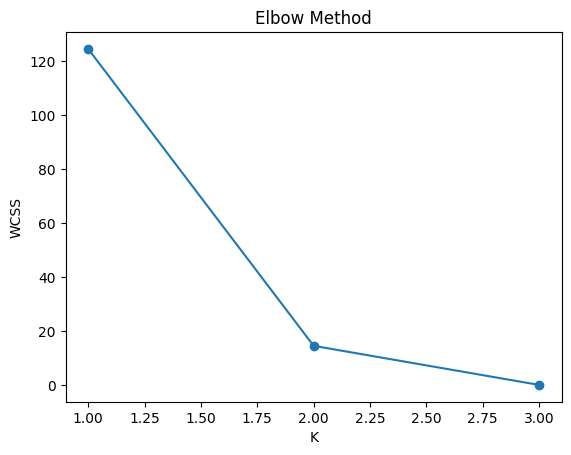

In [37]:
# elbow plot to find optimal k 
wcss = []
for k in range(1, 4):
    km = KMeans(n_clusters=k)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 4), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

## v. As we can see, the manual kmeans calculations corroborates the elbow method. They both suggest K = 2. 

In [38]:
# define k = 2 
kmeans = KMeans(n_clusters=2)
y_pred = kmeans.fit_predict(X)

print("Cluster Centers:\n", kmeans.cluster_centers_)
print("WCSS:", kmeans.inertia_)

Cluster Centers:
 [[27.5  4. ]
 [40.   7. ]]
WCSS: 14.5


## v. Again, the manual calculations and kmeans have the same answers. 

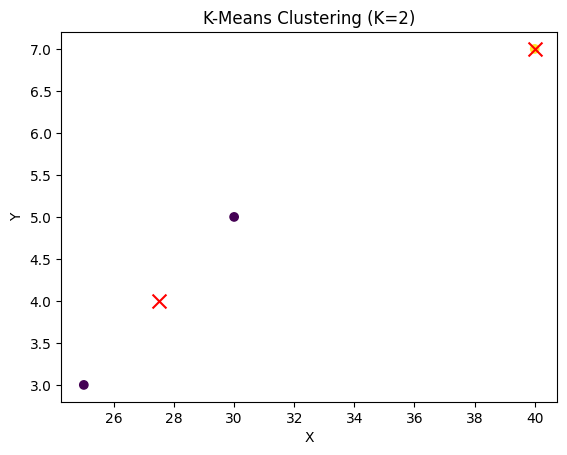

In [39]:
# Visualization
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            c='red', marker='x', s=100)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering (K=2)")
plt.show()